# Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay, f1_score

# Configuration for plots
%matplotlib inline
sns.set(style="whitegrid")

# Load Data and Models

In [2]:
# Load the processed test data and labels
print("Loading data...")
X_test = np.load('X_test_processed.npy')
y_test = np.load('y_test.npy')
class_names = np.load('classes.npy', allow_pickle=True)

# Load the trained models
print("Loading models...")
models = {
    "KNN": joblib.load('knn_model.pkl'),
    "SVM": joblib.load('svm_model.pkl'),
    "Random Forest": joblib.load('rf_model.pkl')
}

print("Data and models loaded successfully.")
print(f"Test Set Shape: {X_test.shape}")
print(f"Classes: {class_names}")

Loading data...
Loading models...
Data and models loaded successfully.
Test Set Shape: (192, 9)
Classes: ['German' 'Italian' 'Korean' 'Spanish']


# Define Evaluation Helper Function

In [3]:
# Dictionary to store metrics for comparison
results = {
    'Model': [],
    'Accuracy': [],
    'F1 Score (Macro)': []
}

def evaluate_model(name, model, X, y):
    """
    Predicts, prints report, updates results dict, and plots confusion matrix.
    """
    print(f"\n{'='*20} Evaluation: {name} {'='*20}")
    
    # Predict
    y_pred = model.predict(X)
    
    # Calculate Metrics
    acc = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred, average='macro')
    
    # Store results
    results['Model'].append(name)
    results['Accuracy'].append(acc)
    results['F1 Score (Macro)'].append(f1)
    
    # Print Classification Report
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score (Macro): {f1:.4f}\n")
    print("Classification Report:")
    print(classification_report(y, y_pred, target_names=class_names))
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    plt.title(f"Confusion Matrix - {name}")
    plt.grid(False)
    plt.show()

# Evaluate Classification Models


==================== Evaluation: KNN ====================
Accuracy: 0.9948
F1 Score (Macro): 0.9946

Classification Report:
              precision    recall  f1-score   support

      German       1.00      0.98      0.99        42
     Italian       0.98      1.00      0.99        51
      Korean       1.00      1.00      1.00        53
     Spanish       1.00      1.00      1.00        46

    accuracy                           0.99       192
   macro avg       1.00      0.99      0.99       192
weighted avg       0.99      0.99      0.99       192



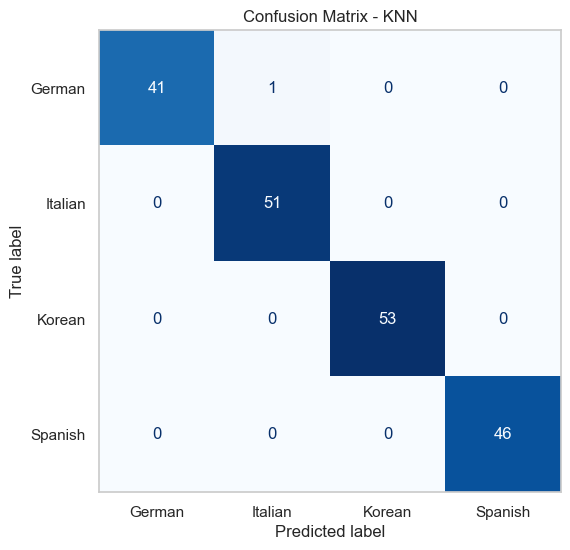


==================== Evaluation: SVM ====================
Accuracy: 0.9896
F1 Score (Macro): 0.9898

Classification Report:
              precision    recall  f1-score   support

      German       1.00      0.98      0.99        42
     Italian       0.96      1.00      0.98        51
      Korean       1.00      0.98      0.99        53
     Spanish       1.00      1.00      1.00        46

    accuracy                           0.99       192
   macro avg       0.99      0.99      0.99       192
weighted avg       0.99      0.99      0.99       192



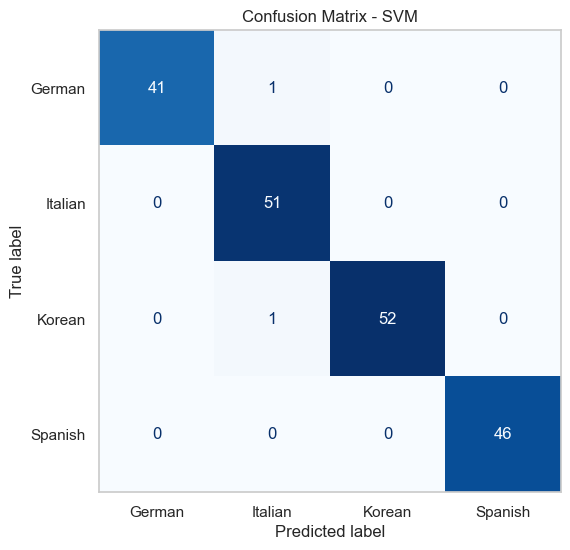


==================== Evaluation: Random Forest ====================
Accuracy: 0.9531
F1 Score (Macro): 0.9530

Classification Report:
              precision    recall  f1-score   support

      German       0.95      0.90      0.93        42
     Italian       0.89      0.98      0.93        51
      Korean       0.98      0.94      0.96        53
     Spanish       1.00      0.98      0.99        46

    accuracy                           0.95       192
   macro avg       0.96      0.95      0.95       192
weighted avg       0.96      0.95      0.95       192



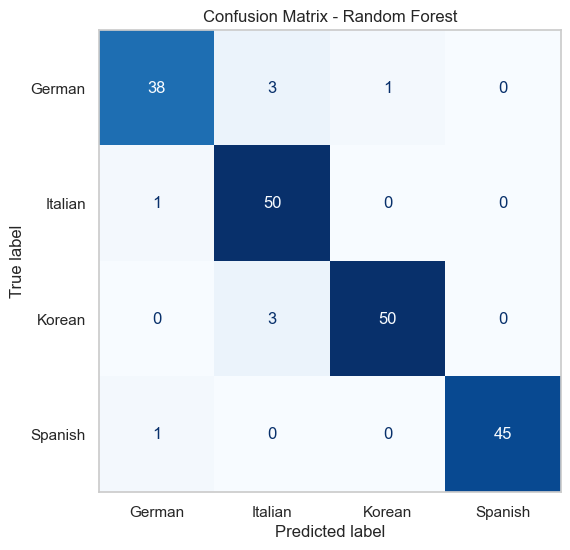

In [4]:
# Iterate through loaded models and evaluate each one
for name, model in models.items():
    evaluate_model(name, model, X_test, y_test)

# Model Comparison Visualization

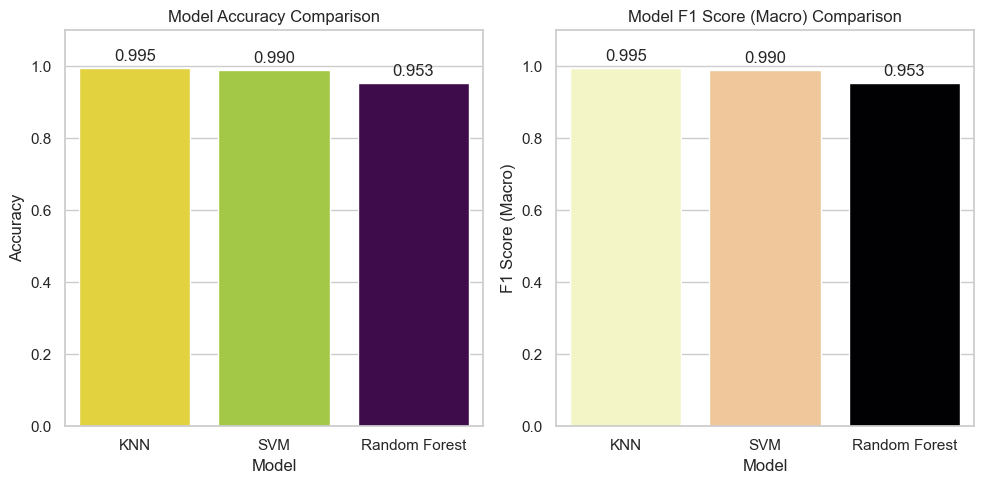

In [9]:
# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Plot Comparison
plt.figure(figsize=(10, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis', hue='Accuracy', legend=False)
plt.ylim(0, 1.1)
plt.title("Model Accuracy Comparison")
for index, row in results_df.iterrows():
    plt.text(index, row.Accuracy + 0.02, f"{row.Accuracy:.3f}", ha='center')

# Plot F1 Score
plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='F1 Score (Macro)', data=results_df, palette='magma', hue='F1 Score (Macro)', legend=False)
plt.ylim(0, 1.1)
plt.title("Model F1 Score (Macro) Comparison")
for index, row in results_df.iterrows():
    plt.text(index, row['F1 Score (Macro)'] + 0.02, f"{row['F1 Score (Macro)']:.3f}", ha='center')

plt.tight_layout()
plt.show()

# Clustering Evaluation (Placeholder)

In [ ]:
print("="*40)
print("       CLUSTERING EVALUATION")
print("="*40)

# PLACEHOLDER: This section will be populated after running Clustering.ipynb
# Required steps for Clustering Evaluation:
# 1. Load clustering results (labels) or the trained clustering models.
# 2. Calculate Silhouette Score.
# 3. Analyze Cluster Purity (if true labels are available).
# 4. Visualize clusters using PCA or t-SNE.

print("Waiting for Clustering results...")

# Example structure for future implementation:
# from sklearn.metrics import silhouette_score
# score = silhouette_score(X_test, cluster_labels)
# print(f"Silhouette Score: {score}")